## Red Neuronal Convolucional con Batch Normalization

<h3>Objetivo</h3>
<h5>Aprender cómo comparar una Red Neuronal Convolucional usando Batch Normalization con una Red Neuronal Convolucional regular para clasificar dígitos escritos a mano de la base de datos MNIST.</h5>

Leer sobre Batch Normalization para la operación de convolución.

Al igual que en una red completamente conectada, creamos un objeto `BatchNorm2d`, pero lo aplicamos al objeto de convolución 2D. Primero, creamos objetos `Conv2d`; necesitamos el número de canales de salida, especificado por la variable `OUT`.

<code>self.cnn1 = nn.Conv2d(in_channels=1, out_channels=OUT, kernel_size=5, padding=2) </code>


Luego creamos un objeto de Batch Normalization para convolución 2D de la siguiente manera:

<code>self.conv1_bn = nn.BatchNorm2d(OUT)</code>

El parámetro `out` es el número de canales en la salida. Luego podemos aplicar Batch Normalization después de la operación de convolución:

<code>x = self.cnn1(x)</code>
 <code> x=self.conv1_bn(x)</code>

In [1]:
#!pip install torchvision==0.9.1 torch==1.8.1
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
import matplotlib.pylab as plt
import numpy as np
def show_data(data_sample):
    plt.imshow(data_sample[0].numpy().reshape(IMAGE_SIZE, IMAGE_SIZE), cmap='gray')
    plt.title('y = '+ str(data_sample[1]))

### Consigue los datos

Creamos una transformación para redimensionar la imagen y convertirla en un tensor:

In [2]:
IMAGE_SIZE = 16

composed = transforms.Compose([transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), transforms.ToTensor()])

Cargar el conjunto de datos de entrenamiento estableciendo el parámetro `train` en `True`. Usamos la transformación definida anteriormente.

In [3]:
train_dataset = dsets.MNIST(root='./data', train=True, download=True, transform=composed)

Cargar el conjunto de datos de prueba estableciendo el parámetro `train` en `False`.

In [4]:
# Make the validating

validation_dataset = dsets.MNIST(root='./data', train=False, download=True, transform=composed)

Podemos ver que el tipo de dato es long.

In [5]:
# Show the data type for each element in dataset

type(train_dataset[0][1])

int

Cada elemento del tensor rectangular corresponde a un número que representa la intensidad de un píxel, como se muestra en la siguiente imagen.

<img src="https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/notebook_images%20/chapter%206/6.2.1imagenet.png" width="550" alt="MNIST data image">

Imprime la cuarta etiqueta

In [6]:
# The label for the fourth data element

train_dataset[3][1]

1

Grafica el cuarto ejemplo

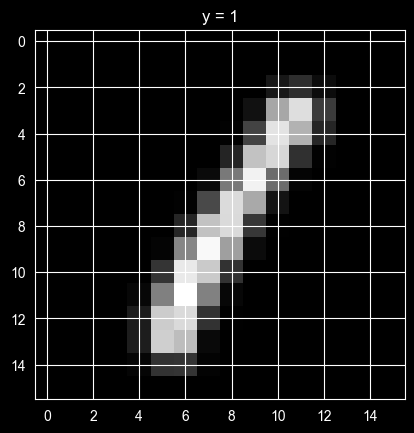

In [7]:
# The image for the fourth data element
show_data(train_dataset[3])


El cuarto ejemplo es un "1"

### Construir una clase de Red Neuronal Convolucional con dos capas.

Construir una clase de Red Neuronal Convolucional con dos capas convolucionales y una capa completamente conectada.

Predeterminar el tamaño de la matriz de salida final.

Los parámetros en el constructor son el número de canales de salida para la primera y la segunda capa.

In [8]:
class CNN(nn.Module):

    # Contructor
    def __init__(self, out_1=16, out_2=32):
        super(CNN, self).__init__()
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=out_1, kernel_size=5, padding=2)
        self.maxpool1=nn.MaxPool2d(kernel_size=2)

        self.cnn2 = nn.Conv2d(in_channels=out_1, out_channels=out_2, kernel_size=5, stride=1, padding=2)
        self.maxpool2=nn.MaxPool2d(kernel_size=2)
        self.fc1 = nn.Linear(out_2 * 4 * 4, 10)

    # Prediction
    def forward(self, x):
        x = self.cnn1(x)
        x = torch.relu(x)
        x = self.maxpool1(x)
        x = self.cnn2(x)
        x = torch.relu(x)
        x = self.maxpool2(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

Construir una clase de Red Neuronal Convolucional con dos capas convolucionales y una capa completamente conectada, agregando Batch Normalization para las capas convolucionales.

In [9]:
class CNN_batch(nn.Module):

    # Contructor
    def __init__(self, out_1=16, out_2=32,number_of_classes=10):
        super(CNN_batch, self).__init__()
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=out_1, kernel_size=5, padding=2)
        self.conv1_bn = nn.BatchNorm2d(out_1)

        self.maxpool1=nn.MaxPool2d(kernel_size=2)

        self.cnn2 = nn.Conv2d(in_channels=out_1, out_channels=out_2, kernel_size=5, stride=1, padding=2)
        self.conv2_bn = nn.BatchNorm2d(out_2)

        self.maxpool2=nn.MaxPool2d(kernel_size=2)
        self.fc1 = nn.Linear(out_2 * 4 * 4, number_of_classes)
        self.bn_fc1 = nn.BatchNorm1d(10)

    # Prediction
    def forward(self, x):
        x = self.cnn1(x)
        x=self.conv1_bn(x)
        x = torch.relu(x)
        x = self.maxpool1(x)
        x = self.cnn2(x)
        x=self.conv2_bn(x)
        x = torch.relu(x)
        x = self.maxpool2(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x=self.bn_fc1(x)
        return x

Función para entrenar el modelo

In [10]:
def train_model(model,train_loader,validation_loader,optimizer,n_epochs=4):

    #global variable
    N_test=len(validation_dataset)
    accuracy_list=[]
    loss_list=[]
    for epoch in range(n_epochs):
        for x, y in train_loader:
            model.train()
            optimizer.zero_grad()
            z = model(x)
            loss = criterion(z, y)
            loss.backward()
            optimizer.step()
            loss_list.append(loss.data)

        correct=0
        #perform a prediction on the validation  data
        for x_test, y_test in validation_loader:
            model.eval()
            z = model(x_test)
            _, yhat = torch.max(z.data, 1)
            correct += (yhat == y_test).sum().item()
        accuracy = correct / N_test
        accuracy_list.append(accuracy)

    return accuracy_list, loss_list

Definir el clasificador de Red Neuronal Convolucional, la función de criterio, el optimizador y entrenar el modelo.

Hay 16 canales de salida para la primera capa y 32 canales de salida para la segunda capa.

In [11]:
# Create the model object using CNN class
model = CNN(out_1=16, out_2=32)

Definir la función de pérdida, el optimizador y el cargador del conjunto de datos.

In [12]:
criterion = nn.CrossEntropyLoss()
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=100)
validation_loader = torch.utils.data.DataLoader(dataset=validation_dataset, batch_size=5000)

Entrenar el modelo y determinar la precisión de validación, técnicamente la precisión de prueba (esto puede tomar mucho tiempo).

In [13]:
# Train the model
accuracy_list_normal, loss_list_normal=train_model(model=model,n_epochs=10,train_loader=train_loader,validation_loader=validation_loader,optimizer=optimizer)

Repetir el proceso para el **modelo con Batch Normalization.

In [14]:
model_batch=CNN_batch(out_1=16, out_2=32)
criterion = nn.CrossEntropyLoss()
learning_rate = 0.1
optimizer = torch.optim.SGD(model_batch.parameters(), lr = learning_rate)
accuracy_list_batch, loss_list_batch=train_model(model=model_batch,n_epochs=10,train_loader=train_loader,validation_loader=validation_loader,optimizer=optimizer)

### Analísis de resultados

Graficar la pérdida de ambas redes.

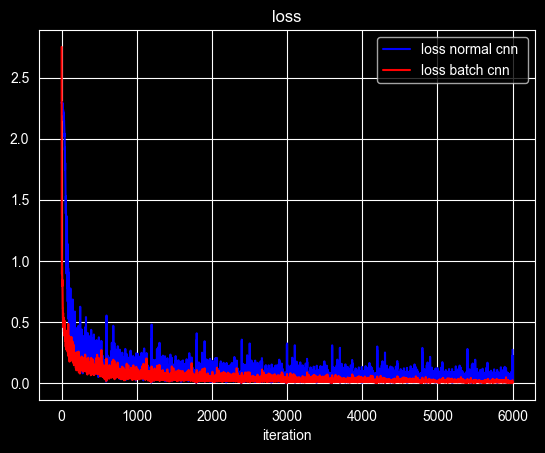

In [15]:
# Plot the loss and accuracy

plt.plot(loss_list_normal, 'b',label='loss normal cnn ')
plt.plot(loss_list_batch,'r',label='loss batch cnn')
plt.xlabel('iteration')
plt.title("loss")
plt.legend()

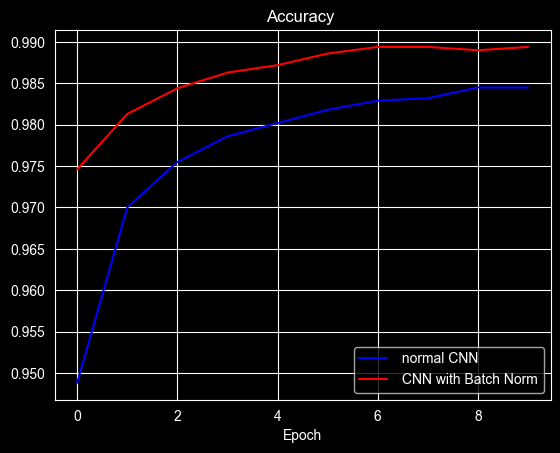

In [16]:
plt.plot(accuracy_list_normal, 'b',label=' normal CNN')
plt.plot(accuracy_list_batch,'r',label=' CNN with Batch Norm')
plt.xlabel('Epoch')
plt.title("Accuracy ")
plt.legend()
plt.show()

Vemos que la CNN con Batch Normalization tiene un mejor desempeño, con una convergencia más rápida.